# 🏋️ Notebook 4 — Predictive Modelling: Will the Motion Pass?
**Input:** `speeches_final.csv`

| # | Model | Feature set |
|---|---|---|
| 1 | **XGBoost** | Structured + party + RobBERT sentiment/tone |
| 2 | **Logistic Regression** | Same + StandardScaler |
| 3 | **RobBERT Classifier** | Raw `speech_text_clean` (full text) |

**Metrics:** Accuracy · F1 · ROC-AUC · Brier · Confusion matrix


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PATH CONFIGURATION  — edit only this cell if you move files around
# ─────────────────────────────────────────────────────────────────────────────
import os
from pathlib import Path

def _detect_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

IN_COLAB = _detect_colab()

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    # ▶ Change this to your own Drive folder if needed
    DATA_DIR = Path("/content/drive/MyDrive/parliament_project")
else:
    # ▶ Change this to wherever your CSV / JSON files live locally
    DATA_DIR = Path("data")

DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Environment : {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Data folder : {DATA_DIR.resolve()}")

# ── convenience helpers ───────────────────────────────────────────────────────
def dp(filename):
    """Return full Path for a data file."""
    return DATA_DIR / filename


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.ticker as mtick
import seaborn as sns, json, warnings, os
warnings.filterwarnings('ignore')
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, brier_score_loss,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader, Dataset

plt.rcParams.update({'figure.dpi':130,'axes.spines.top':False,'axes.spines.right':False})
BLUE,RED,GREEN,ORANGE = '#2B5797','#C0392B','#27AE60','#E67E22'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

df = pd.read_csv(dp("speeches_with_sentiment.csv"), low_memory=False)
with open(dp("class_meta.json")) as f: class_meta = json.load(f)
with open(dp("feature_cols.json")) as f: feat_meta = json.load(f)
SPW = class_meta['scale_pos_weight']
print(f"Loaded {len(df):,} rows | scale_pos_weight = {SPW}")

Device: cuda
Loaded 30,149 rows | scale_pos_weight = 0.9735


In [4]:
# Define feature columns
STRUCTURED_COLS  = feat_meta['structured']
PARTY_COLS       = feat_meta['party']

ROBBERT_FEAT = [
    'sentiment_score',
    'sentiment_label_enc'
]

ALL_FEAT = STRUCTURED_COLS + PARTY_COLS + [
    c for c in ROBBERT_FEAT if c in df.columns
]

In [5]:
from sklearn.model_selection import train_test_split

# Features and labels
X = df[ALL_FEAT].fillna(0).astype(float)
y = df['label'].astype(int)

# 1️⃣ Train vs temp (80 / 20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 2️⃣ Val vs test (10 / 10)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {len(X_train):,}")
print(f"Val:   {len(X_val):,}")
print(f"Test:  {len(X_test):,}")

Train: 24,119
Val:   3,015
Test:  3,015


## Model 1 — XGBoost

In [6]:
xgb_p = dict(n_estimators=600,max_depth=6,learning_rate=0.05,subsample=0.8,
              colsample_bytree=0.8,min_child_weight=5,gamma=0.1,reg_alpha=0.1,
              reg_lambda=1.0,scale_pos_weight=SPW,eval_metric='logloss',
              random_state=42,n_jobs=-1)
xgb = XGBClassifier(**xgb_p)
xgb.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=100)
print("XGBoost ✓")

[0]	validation_0-logloss:0.69108
[100]	validation_0-logloss:0.67470
[200]	validation_0-logloss:0.67786
[300]	validation_0-logloss:0.67904
[400]	validation_0-logloss:0.67987
[500]	validation_0-logloss:0.68079
[599]	validation_0-logloss:0.68111
XGBoost ✓


In [7]:
def evaluate(model, X, y, name):
    preds = model.predict(X); probas = model.predict_proba(X)[:,1]
    return {'model':name,'accuracy':accuracy_score(y,preds),'f1':f1_score(y,preds),
            'roc_auc':roc_auc_score(y,probas),'brier':brier_score_loss(y,probas),
            '_preds':preds,'_probas':probas,'_y':y}

xgb_r = evaluate(xgb, X_test, y_test, 'XGBoost')
print(f"XGBoost Test — Acc:{xgb_r['accuracy']:.4f} F1:{xgb_r['f1']:.4f} AUC:{xgb_r['roc_auc']:.4f}")
print(classification_report(y_test, xgb_r['_preds'], target_names=['Rejected','Passed']))

XGBoost Test — Acc:0.5585 F1:0.5446 AUC:0.5991
              precision    recall  f1-score   support

    Rejected       0.55      0.60      0.57      1487
      Passed       0.57      0.52      0.54      1528

    accuracy                           0.56      3015
   macro avg       0.56      0.56      0.56      3015
weighted avg       0.56      0.56      0.56      3015



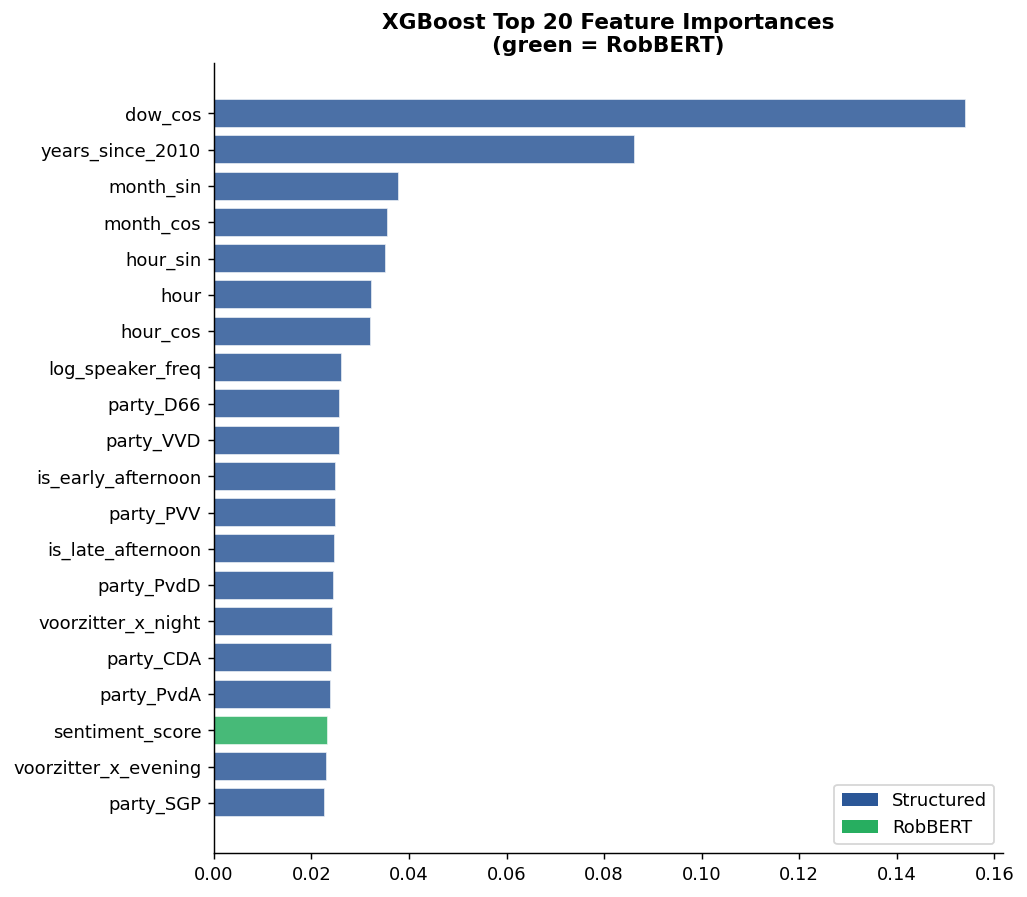

In [8]:
fi = pd.Series(xgb.feature_importances_, index=ALL_FEAT).sort_values(ascending=True).tail(20)
fig, ax = plt.subplots(figsize=(8,7))
is_rb = [any(x in n for x in ['sentiment','tone']) for n in fi.index]
ax.barh(fi.index, fi.values, color=[GREEN if r else BLUE for r in is_rb], edgecolor='white', alpha=0.85)
ax.set_title('XGBoost Top 20 Feature Importances\n(green = RobBERT)', fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=BLUE,label='Structured'),Patch(facecolor=GREEN,label='RobBERT')])
plt.tight_layout(); plt.show()

In [9]:
X_tv = pd.concat([X_train,X_val]); y_tv = pd.concat([y_train,y_val])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_aucs, cv_f1s = [], []
for fold,(tr,va) in enumerate(cv.split(X_tv,y_tv)):
    m = XGBClassifier(**xgb_p)
    m.fit(X_tv.iloc[tr], y_tv.iloc[tr], verbose=False)
    p = m.predict_proba(X_tv.iloc[va])[:,1]; pd_ = m.predict(X_tv.iloc[va])
    cv_aucs.append(roc_auc_score(y_tv.iloc[va],p)); cv_f1s.append(f1_score(y_tv.iloc[va],pd_))
    print(f"  Fold {fold+1}: AUC={cv_aucs[-1]:.4f}  F1={cv_f1s[-1]:.4f}")
print(f"\n  CV AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")
print(f"  CV F1 : {np.mean(cv_f1s):.4f} ± {np.std(cv_f1s):.4f}")

  Fold 1: AUC=0.5988  F1=0.5540
  Fold 2: AUC=0.5933  F1=0.5550
  Fold 3: AUC=0.5916  F1=0.5442
  Fold 4: AUC=0.6048  F1=0.5714
  Fold 5: AUC=0.5887  F1=0.5453

  CV AUC: 0.5955 ± 0.0057
  CV F1 : 0.5540 ± 0.0097


## Model 2 — Logistic Regression

In [10]:
lr_pipe = Pipeline([('scaler',StandardScaler()),
                    ('lr',LogisticRegressionCV(Cs=[0.001,0.01,0.1,1.0,10.0,100.0],
                         cv=5,scoring='roc_auc',penalty='l2',solver='lbfgs',
                         max_iter=2000,class_weight='balanced',random_state=42,n_jobs=-1))])
X_tv = pd.concat([X_train,X_val]); y_tv = pd.concat([y_train,y_val])
lr_pipe.fit(X_tv, y_tv)
lr_r = evaluate(lr_pipe, X_test, y_test, 'LogisticReg')
print(f"Best C: {lr_pipe.named_steps['lr'].C_[0]}")
print(f"LR Test — Acc:{lr_r['accuracy']:.4f} F1:{lr_r['f1']:.4f} AUC:{lr_r['roc_auc']:.4f}")
print(classification_report(y_test, lr_r['_preds'], target_names=['Rejected','Passed']))

Best C: 10.0
LR Test — Acc:0.5721 F1:0.5570 AUC:0.6001
              precision    recall  f1-score   support

    Rejected       0.56      0.61      0.59      1487
      Passed       0.59      0.53      0.56      1528

    accuracy                           0.57      3015
   macro avg       0.57      0.57      0.57      3015
weighted avg       0.57      0.57      0.57      3015



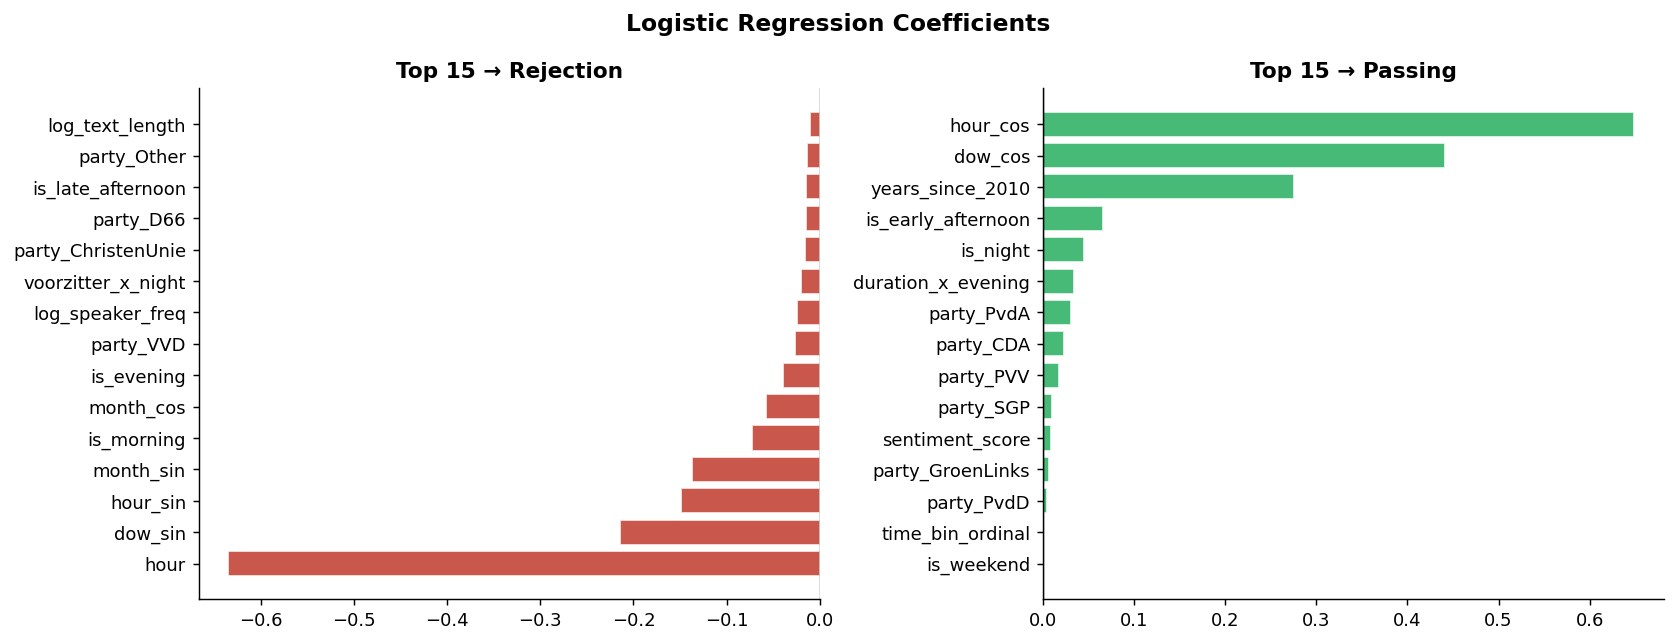

In [11]:
coef = lr_pipe.named_steps['lr'].coef_[0]
cs   = pd.Series(coef, index=ALL_FEAT).sort_values()
fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax, data, title in [(axes[0],cs.head(15),'Top 15 → Rejection'),(axes[1],cs.tail(15),'Top 15 → Passing')]:
    ax.barh(data.index, data.values, color=[RED if v<0 else GREEN for v in data.values], edgecolor='white', alpha=0.85)
    ax.axvline(0,color='black',lw=0.7); ax.set_title(title,fontweight='bold')
plt.suptitle('Logistic Regression Coefficients', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

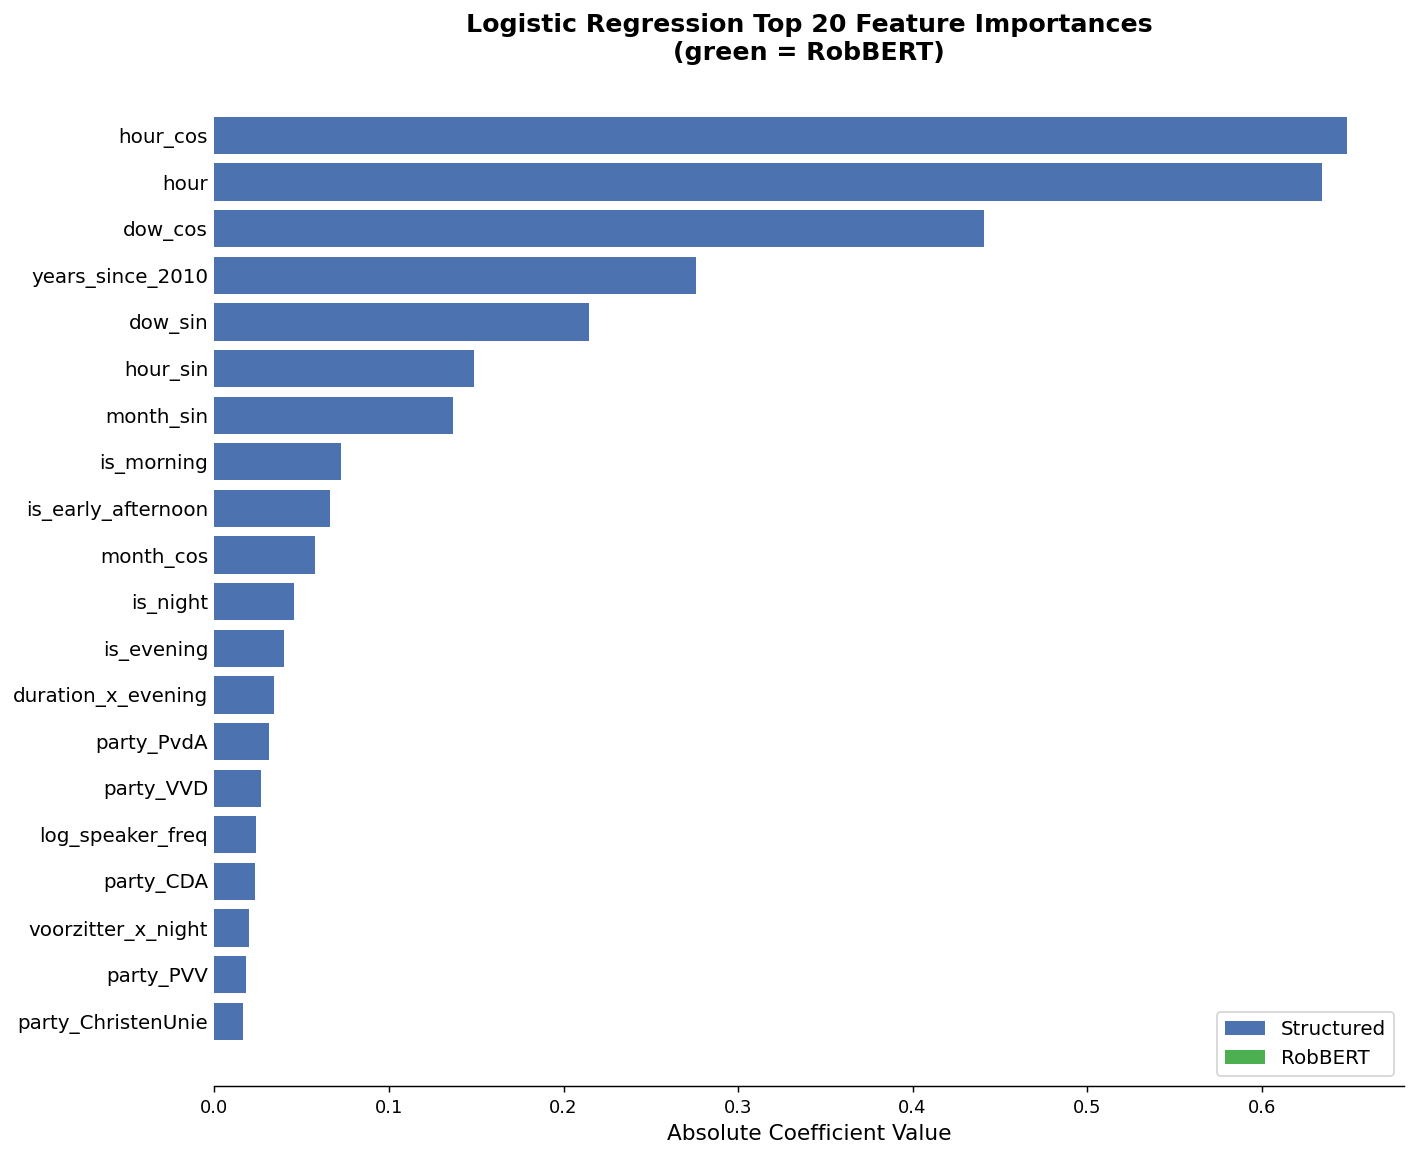

In [16]:
lr_model = lr_pipe.named_steps['lr']
coefficients = lr_model.coef_[0]

feature_names = X_tv.columns.tolist()

importance = np.abs(coefficients)

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance,
    'coefficient': coefficients
}).sort_values('importance', ascending=False)

top20 = feat_imp.head(20).sort_values('importance', ascending=True)

robbert_features = {'sentiment_score'}

colors = [
    '#4CAF50' if f in robbert_features else '#4C72B0'
    for f in top20['feature']
]

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(top20['feature'], top20['importance'], color=colors, edgecolor='none')

ax.set_xlabel('Absolute Coefficient Value', fontsize=12)
ax.set_title('Logistic Regression Top 20 Feature Importances\n(green = RobBERT)', fontsize=14, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', labelsize=10)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'], fontsize=11)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='Structured'),
    Patch(facecolor='#4CAF50', label='RobBERT')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig('lr_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Model 3 — RobBERT Sequence Classifier

In [ ]:
ROBBERT_BASE = "pdelobelle/robbert-v2-dutch-base"

class SpeechDS(Dataset):
    def __init__(self, texts, labels, tok, max_len=512):
        self.enc = tok(texts, truncation=True, padding='max_length', max_length=max_len, return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k:v[i] for k,v in self.enc.items()}; item['labels']=self.labels[i]; return item

rb_tok = AutoTokenizer.from_pretrained(ROBBERT_BASE)
print("Tokenizer loaded ✓")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Tokenizer loaded ✓


In [ ]:
tc = 'speech_text_clean' if 'speech_text_clean' in df.columns else 'speech_text'
all_t = df[tc].fillna('').tolist(); all_l = df['label'].astype(int).tolist(); all_s = df['split'].tolist()

def get_split(s): idx=[i for i,sp in enumerate(all_s) if sp==s]; return [all_t[i] for i in idx],[all_l[i] for i in idx]
tr_t,tr_l = get_split('train'); va_t,va_l = get_split('val'); te_t,te_l = get_split('test')

n_p = sum(tr_l); n_r = len(tr_l)-n_p
cw  = torch.tensor([1.0, n_r/n_p], dtype=torch.float).to(DEVICE)
print(f"Class weights: [rejected=1.0, passed={n_r/n_p:.2f}]")

BATCH = 16
train_dl = DataLoader(SpeechDS(tr_t,tr_l,rb_tok), batch_size=BATCH, shuffle=True)
val_dl   = DataLoader(SpeechDS(va_t,va_l,rb_tok), batch_size=BATCH)
test_dl  = DataLoader(SpeechDS(te_t,te_l,rb_tok), batch_size=BATCH)
print(f"DataLoaders ready — {len(train_dl)} train batches")

Class weights: [rejected=1.0, passed=0.97]
DataLoaders ready — 1508 train batches


In [ ]:
rb_model = AutoModelForSequenceClassification.from_pretrained(ROBBERT_BASE, num_labels=2)
rb_model.to(DEVICE)
print(f"RobBERT loaded  |  {sum(p.numel() for p in rb_model.parameters()):,} parameters")

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: pdelobelle/robbert-v2-dutch-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobBERT loaded  |  116,763,650 parameters


In [ ]:
def eval_bert(model, loader):
    model.eval(); preds_a,probs_a,labels_a=[],[],[]
    with torch.no_grad():
        for batch in loader:
            ids=batch['input_ids'].to(DEVICE); mask=batch['attention_mask'].to(DEVICE)
            out=rb_model(input_ids=ids,attention_mask=mask)
            probs_a.extend(torch.softmax(out.logits.cpu(),dim=-1)[:,1].tolist())
            preds_a.extend(torch.argmax(out.logits.cpu(),dim=-1).tolist())
            labels_a.extend(batch['labels'].tolist())
    return np.array(preds_a), np.array(probs_a), np.array(labels_a)

EPOCHS=6; LR=2e-5
optimizer = torch.optim.AdamW(rb_model.parameters(), lr=LR, weight_decay=0.01)
total_st  = len(train_dl)*EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, int(total_st*0.1), total_st)
loss_fn   = torch.nn.CrossEntropyLoss(weight=cw)
best_auc  = 0.0; history = []

print("Phase 1 (ep 1-2): classifier head only ...")
for p in rb_model.roberta.parameters(): p.requires_grad=False

for epoch in range(EPOCHS):
    if epoch==2:
        print("Phase 2: full fine-tuning ...")
        for p in rb_model.roberta.parameters(): p.requires_grad=True
        for g in optimizer.param_groups: g['lr']=LR/5
    rb_model.train(); total_loss=0.0
    for batch in train_dl:
        ids=batch['input_ids'].to(DEVICE); mask=batch['attention_mask'].to(DEVICE); lbs=batch['labels'].to(DEVICE)
        optimizer.zero_grad(); out=rb_model(input_ids=ids,attention_mask=mask)
        loss=loss_fn(out.logits,lbs); loss.backward()
        torch.nn.utils.clip_grad_norm_(rb_model.parameters(),1.0)
        optimizer.step(); scheduler.step(); total_loss+=loss.item()
    avg_loss=total_loss/l_model,val_dl)
    vauc=roc_auc_score(vy,en(train_dl)
    vp,vpr,vy=eval_bert(rbvpr); vf1=f1_score(vy,vp)
    history.append({'epoch':epoch+1,'loss':avg_loss,'val_auc':vauc,'val_f1':vf1})
    print(f"  Ep {epoch+1}/{EPOCHS} | loss={avg_loss:.4f} | val_auc={vauc:.4f} | val_f1={vf1:.4f}")
    if vauc>best_auc: best_auc=vauc; torch.save(rb_model.state_dict(),"robbert_best.pt"); print(f"    → saved best (auc={best_auc:.4f})")

print("Training complete ✓")

Phase 1 (ep 1-2): classifier head only ...
  Ep 1/6 | loss=0.6957 | val_auc=0.5467 | val_f1=0.5342
    → saved best (auc=0.5467)
  Ep 2/6 | loss=0.6916 | val_auc=0.5564 | val_f1=0.4166
    → saved best (auc=0.5564)
Phase 2: full fine-tuning ...
  Ep 3/6 | loss=0.6929 | val_auc=0.5803 | val_f1=0.3174
    → saved best (auc=0.5803)
  Ep 4/6 | loss=0.6824 | val_auc=0.5968 | val_f1=0.5804
    → saved best (auc=0.5968)
  Ep 5/6 | loss=0.6766 | val_auc=0.5923 | val_f1=0.4752
  Ep 6/6 | loss=0.6718 | val_auc=0.5975 | val_f1=0.5958
    → saved best (auc=0.5975)
Training complete ✓


In [ ]:
rb_model.load_state_dict(torch.load("robbert_best.pt", map_location=DEVICE))
rb_preds,rb_probs,rb_labels = eval_bert(rb_model, test_dl)
rb_r = {'model':'RobBERT','accuracy':accuracy_score(rb_labels,rb_preds),
        'f1':f1_score(rb_labels,rb_preds),'roc_auc':roc_auc_score(rb_labels,rb_probs),
        'brier':brier_score_loss(rb_labels,rb_probs),'_preds':rb_preds,'_probas':rb_probs,'_y':rb_labels}
print(f"RobBERT Test — Acc:{rb_r['accuracy']:.4f} F1:{rb_r['f1']:.4f} AUC:{rb_r['roc_auc']:.4f}")
print(classification_report(rb_labels,rb_preds,target_names=['Rejected','Passed']))

RobBERT Test — Acc:0.5589 F1:0.5849 AUC:0.5972
              precision    recall  f1-score   support

    Rejected       0.56      0.50      0.53      1487
      Passed       0.56      0.61      0.58      1528

    accuracy                           0.56      3015
   macro avg       0.56      0.56      0.56      3015
weighted avg       0.56      0.56      0.56      3015



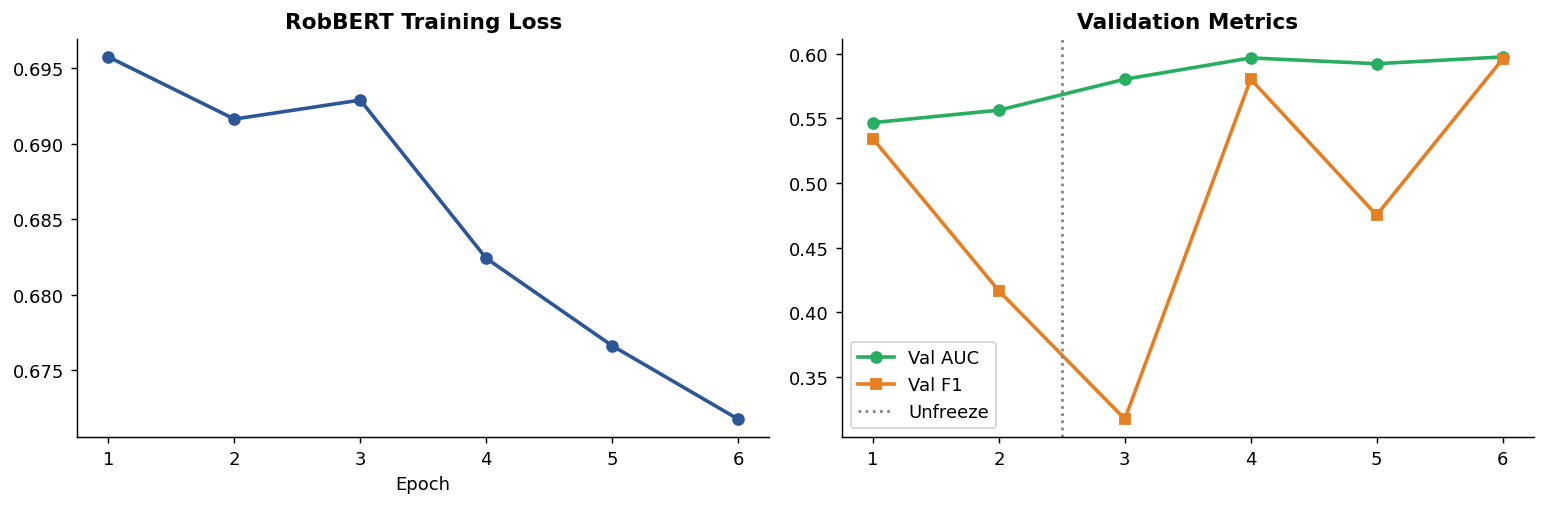

In [ ]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(hist_df['epoch'],hist_df['loss'],marker='o',color=BLUE,lw=2)
axes[0].set_title('RobBERT Training Loss',fontweight='bold'); axes[0].set_xlabel('Epoch')
axes[1].plot(hist_df['epoch'],hist_df['val_auc'],marker='o',color=GREEN,lw=2,label='Val AUC')
axes[1].plot(hist_df['epoch'],hist_df['val_f1'],marker='s',color=ORANGE,lw=2,label='Val F1')
axes[1].axvline(2.5,color='grey',linestyle=':',label='Unfreeze')
axes[1].set_title('Validation Metrics',fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.show()

## Model Comparison

In [ ]:
results = [xgb_r, lr_r, rb_r]
summary = pd.DataFrame([{'Model':r['model'],'Accuracy':r['accuracy'],'F1':r['f1'],
                          'ROC-AUC':r['roc_auc'],'Brier↓':r['brier']} for r in results]).sort_values('ROC-AUC',ascending=False)
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

      Model  Accuracy     F1  ROC-AUC  Brier↓
LogisticReg    0.5721 0.5570   0.6001  0.2429
    XGBoost    0.5585 0.5446   0.5991  0.2428
    RobBERT    0.5589 0.5849   0.5972  0.2439


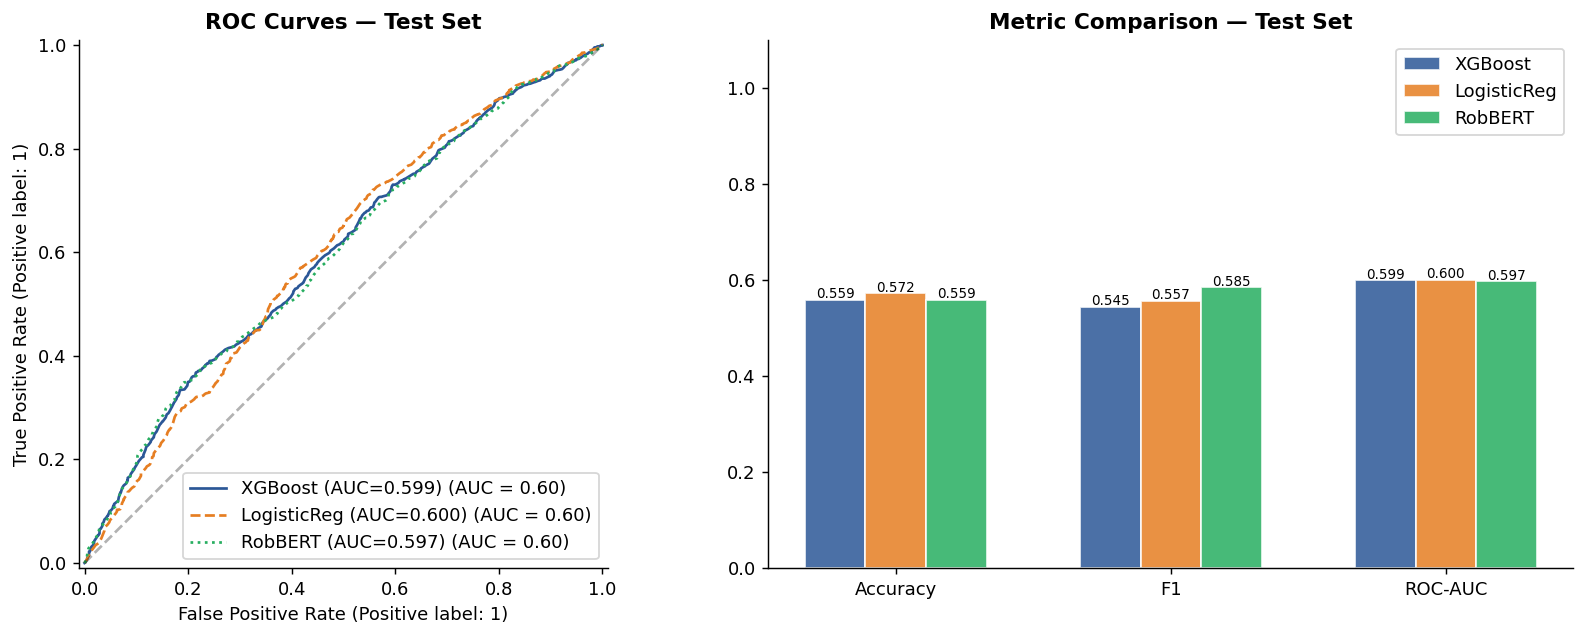

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
ax=axes[0]
for r,color,ls in [(xgb_r,BLUE,'-'),(lr_r,ORANGE,'--'),(rb_r,GREEN,':')]:
    RocCurveDisplay.from_predictions(r['_y'],r['_probas'],name=f"{r['model']} (AUC={r['roc_auc']:.3f})",
                                      ax=ax,color=color,linestyle=ls)
ax.plot([0,1],[0,1],'k--',alpha=0.3); ax.set_title('ROC Curves — Test Set',fontweight='bold')

ax2=axes[1]; metrics=['Accuracy','F1','ROC-AUC']; x=np.arange(3); w=0.22
for i,(r,color) in enumerate([(xgb_r,BLUE),(lr_r,ORANGE),(rb_r,GREEN)]):
    vals=[r['accuracy'],r['f1'],r['roc_auc']]
    bars=ax2.bar(x+i*w,vals,w,label=r['model'],color=color,alpha=0.85,edgecolor='white')
    for bar in bars: ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,f"{bar.get_height():.3f}",ha='center',fontsize=7.5)
ax2.set_xticks(x+w); ax2.set_xticklabels(metrics); ax2.set_ylim(0,1.1); ax2.legend()
ax2.set_title('Metric Comparison — Test Set',fontweight='bold')
plt.tight_layout(); plt.show()

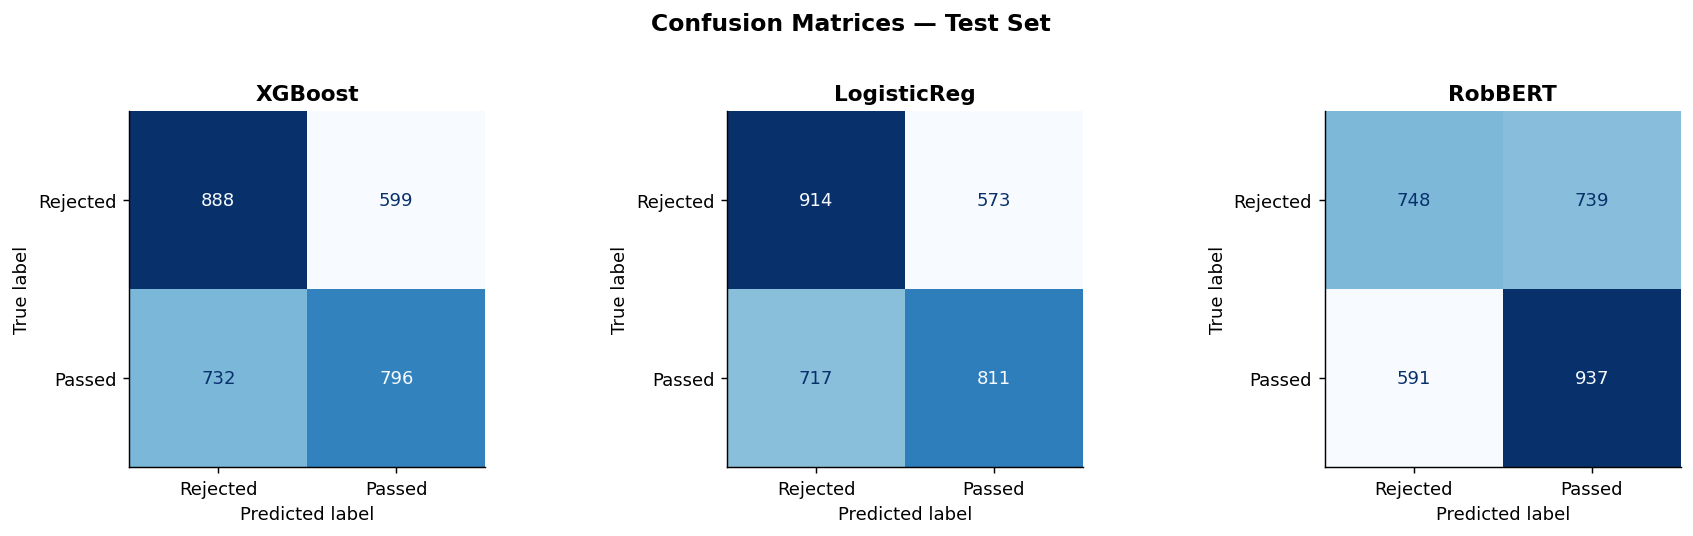

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax,r in zip(axes,results):
    ConfusionMatrixDisplay.from_predictions(r['_y'],r['_preds'],display_labels=['Rejected','Passed'],
                                             ax=ax,colorbar=False,cmap='Blues')
    ax.set_title(r['model'],fontweight='bold')
plt.suptitle('Confusion Matrices — Test Set',fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
import os, json, numpy as np

out_dir = "/content/drive/MyDrive/outputs"
os.makedirs(out_dir, exist_ok=True)

for r in results:
    out = {
        k: (float(v) if isinstance(v, (np.floating, float)) else v)
        for k, v in r.items()
        if not k.startswith('_')
    }
    path = f"{out_dir}/{r['model'].lower()}_results.json"
    with open(path, "w") as f:
        json.dump(out, f, indent=2)
    print(f"Saved {path}")

Saved /content/drive/MyDrive/outputs/xgboost_results.json
Saved /content/drive/MyDrive/outputs/logisticreg_results.json
Saved /content/drive/MyDrive/outputs/robbert_results.json
